# Assignment 5: Transfer Learning for Image Classification
**Objective:** Fine-tune a pre-trained Convolutional Neural Network (ResNet18) to classify images of ducks and chickens.
**Hardware:** GPU Enabled

In [1]:
# Setup and Data Collection
!pip install -q kagglehub

import kagglehub
import os
import shutil
import warnings
warnings.filterwarnings('ignore')

# Download a public Duck vs Chicken dataset from Kaggle
print("Downloading Kaggle dataset...")
path = kagglehub.dataset_download("nothingnone123/chicken-duck-dataset")

# Define our working directory
base_dir = 'duck_chicken_dataset'

# WIPE the old corrupted dataset so we start completely fresh!
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.makedirs(os.path.join(base_dir, 'chicken'), exist_ok=True)
os.makedirs(os.path.join(base_dir, 'duck'), exist_ok=True)

# Helper function to move images from the Kaggle download into our folders
def move_images(source_folder, category):
    count = 0
    for root, dirs, files in os.walk(source_folder):
        # FIXED: Look ONLY at the immediate folder name, not the whole path!
        if category in os.path.basename(root).lower():
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    src = os.path.join(root, file)
                    dst = os.path.join(base_dir, category, f"{category}_{count}.jpg")
                    shutil.copy(src, dst)
                    count += 1
    return count

# Move the images into our standard directory structure
chicken_count = move_images(path, 'chicken')
duck_count = move_images(path, 'duck')

print(f"\nDataset Ready!")
print(f"Imported {chicken_count} Chicken images.")
print(f"Imported {duck_count} Duck images.")

100%|██████████| 22.5M/22.5M [00:00<00:00, 191MB/s]

Extracting files...



Dataset Ready!
Imported 447 Chicken images.
Imported 310 Duck images.


### Data Cleaning and Preprocessing
Removing corrupted downloads, defining transformations (resizing to 224x224 and normalizing for ResNet), and splitting into Train (70%), Validation (15%), and Test (15%) sets.

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from PIL import Image

# Clean corrupted images
for subdir, _, files in os.walk(base_dir):
    for file in files:
        filepath = os.path.join(subdir, file)
        try:
            with Image.open(filepath) as img: img.verify()
        except: os.remove(filepath)

# Transforms
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=base_dir, transform=data_transforms)
class_names = full_dataset.classes

# Splits
total = len(full_dataset)
train_size, val_size = int(0.7 * total), int(0.15 * total)
test_size = total - train_size - val_size

train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 529 | Val: 113 | Test: 115


### Model Initialization and Training
Loading pre-trained ResNet18, freezing the base layers, replacing the classification head, and training for 10 epochs.

In [3]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model.parameters(): param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 25
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

start_time = time.time()
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        dataloader = train_loader if phase == 'train' else val_loader
        dataset_size = len(train_ds) if phase == 'train' else len(val_ds)

        running_loss, running_corrects = 0.0, 0
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())
        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

print(f"Training completed in {(time.time() - start_time)//60:.0f}m {(time.time() - start_time)%60:.0f}s")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 121MB/s]


Epoch 1/25
Train Loss: 0.5263 Acc: 0.7183
Val Loss: 0.2663 Acc: 0.9381
Epoch 2/25
Train Loss: 0.2791 Acc: 0.8998
Val Loss: 0.2068 Acc: 0.9292
Epoch 3/25
Train Loss: 0.1994 Acc: 0.9414
Val Loss: 0.1649 Acc: 0.9646
Epoch 4/25
Train Loss: 0.1727 Acc: 0.9395
Val Loss: 0.1553 Acc: 0.9469
Epoch 5/25
Train Loss: 0.1937 Acc: 0.9319
Val Loss: 0.1446 Acc: 0.9558
Epoch 6/25
Train Loss: 0.1503 Acc: 0.9490
Val Loss: 0.1320 Acc: 0.9558
Epoch 7/25
Train Loss: 0.1646 Acc: 0.9263
Val Loss: 0.1460 Acc: 0.9381
Epoch 8/25
Train Loss: 0.1193 Acc: 0.9546
Val Loss: 0.1161 Acc: 0.9646
Epoch 9/25
Train Loss: 0.1151 Acc: 0.9584
Val Loss: 0.1121 Acc: 0.9735
Epoch 10/25
Train Loss: 0.1239 Acc: 0.9603
Val Loss: 0.1051 Acc: 0.9646
Epoch 11/25
Train Loss: 0.1111 Acc: 0.9622
Val Loss: 0.1575 Acc: 0.9469
Epoch 12/25
Train Loss: 0.1104 Acc: 0.9698
Val Loss: 0.0965 Acc: 0.9646
Epoch 13/25
Train Loss: 0.1144 Acc: 0.9622
Val Loss: 0.0984 Acc: 0.9558
Epoch 14/25
Train Loss: 0.1400 Acc: 0.9546
Val Loss: 0.1031 Acc: 0.9558
E

### Evaluation and Visualizations
Generating loss/accuracy plots and a classification report on the unseen test set.

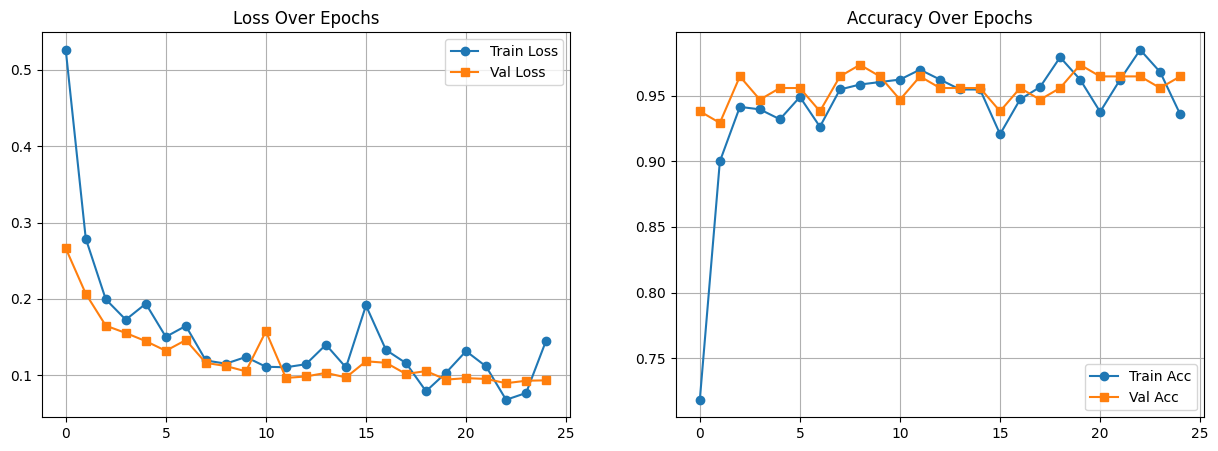


Classification Report (Test Set):
              precision    recall  f1-score   support

     chicken       0.92      0.98      0.95        66
        duck       0.98      0.88      0.92        49

    accuracy                           0.94       115
   macro avg       0.95      0.93      0.94       115
weighted avg       0.94      0.94      0.94       115



In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='s')
ax1.set_title('Loss Over Epochs'); ax1.legend(); ax1.grid(True)

ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='s')
ax2.set_title('Accuracy Over Epochs'); ax2.legend(); ax2.grid(True)
plt.show()

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        preds = torch.max(model(inputs), 1)[1]
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report (Test Set):")
print(classification_report(all_labels, all_preds, target_names=class_names))